In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 15.2.0


# Pulse Radar SAR Imaging: Strip-Map SAR via Back-Projection

**Synthetic Aperture Radar (SAR)** achieves fine azimuth (along-track) resolution by
coherently combining many pulse returns as the radar platform moves, synthesizing a
large virtual aperture.

## Key Principles

### Range Resolution

Determined by pulse bandwidth $B$:

$$\Delta R = \frac{c}{2B}$$

### Azimuth Resolution (Real Aperture)

For a real antenna of length $D_a$:

$$\Delta_{az}^{\text{real}} \approx \frac{\lambda R}{D_a}$$

### Azimuth Resolution (Synthetic Aperture)

SAR synthesizes an aperture of length $L_s = \lambda R / D_a$, giving:

$$\Delta_{az}^{\text{SAR}} \approx \frac{D_a}{2}$$

SAR azimuth resolution is **independent of range and wavelength** — it depends only
on the physical antenna length.

### Back-Projection Algorithm (BPA)

Each image pixel $(x_p, y_p)$ is focused by coherently summing all pulses:

$$I(x_p, y_p) = \sum_{n=0}^{N-1} s_n\!\left(\frac{2 R_n(x_p,y_p)}{c}\right)
  \cdot e^{j 4\pi R_n(x_p,y_p) / \lambda}$$

where $R_n = \sqrt{(x_p - x_n)^2 + y_p^2}$ is the instantaneous slant range from
pulse $n$ at platform position $x_n$ to pixel $(x_p, y_p)$.

## This Example

Strip-map SAR with a moving platform over three point targets:

| Parameter | Value | Notes |
|-----------|-------|-------|
| Carrier frequency | 10 GHz (X-band) | λ ≈ 3 cm |
| Pulse bandwidth | 30 MHz | ΔR ≈ 5 m |
| PRF | 500 Hz | PRP = 2 ms |
| Platform speed | 100 m/s | Along-track |
| Standoff range | 1 000 m | Broadside |
| Antenna length | 1.0 m | Δaz ≈ 0.5 m |
| Number of pulses | 60 | Synthetic aperture |
| Processing | Back-Projection Algorithm (BPA) | |

## Radar System Configuration

### Import Required Modules

In [2]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from IPython.display import Image, display
from scipy import constants
from radarsimpy import Radar, Transmitter, Receiver
from radarsimpy.simulator import sim_radar

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))

### Radar and Waveform Parameters

| Parameter | Formula / Value | Notes |
|-----------|----------------|-------|
| Carrier $f_c$ | 10 GHz | X-band |
| Wavelength $\lambda$ | $c / f_c$ ≈ 3 cm | |
| Bandwidth $B$ | 30 MHz | ΔR = c/(2B) ≈ 5 m |
| Pulse width $T_p$ | 1/B ≈ 33.3 ns | Uncompressed |
| PRF | 500 Hz | |
| PRP | 1/PRF = 2 ms | |
| Sample rate $f_s$ | 60 MHz | 2× bandwidth |
| Pulses $N$ | 60 | Synthetic aperture |

In [3]:
c = constants.c  # Speed of light (m/s)

# ── Carrier / waveform ────────────────────────────────────────────────────────
fc = 10e9          # Carrier frequency (Hz)
lam = c / fc       # Wavelength (m)

B = 30e6           # Pulse bandwidth (Hz)  →  ΔR = c/(2B) ≈ 5 m
pulse_width = 1 / B  # Rectangular pulse width (s)

prf = 500          # Pulse repetition frequency (Hz)
prp = 1 / prf      # Pulse repetition period (s)

fs = 2 * B         # ADC sample rate (Hz) — Nyquist for bandwidth B
tx_power_dbm = 40  # Transmit power (dBm)

num_pulses = 60    # Number of pulses (= synthetic aperture)

# ── Platform / geometry ───────────────────────────────────────────────────────
v_platform = 100.0   # Along-track (x) velocity (m/s)
r0 = 1000.0          # Broadside (y) standoff range (m)

# ── Derived quantities ────────────────────────────────────────────────────────
range_res = c / (2 * B)            # Range resolution (m)
az_res_sar = 0.5                    # Theoretical SAR azimuth resolution (m) = D_a/2
max_range = c / (2 * prf)          # Max unambiguous range (m)
samples_per_pulse = int(prp * fs)  # ADC samples per PRP
aperture_time = num_pulses / prf   # Total dwell time (s)
synthetic_aperture = v_platform * aperture_time  # Synthetic aperture length (m)

print("SAR System Parameters")
print(f"  Carrier frequency  : {fc/1e9:.1f} GHz   (λ = {lam*100:.2f} cm)")
print(f"  Pulse bandwidth    : {B/1e6:.0f} MHz")
print(f"  Pulse width        : {pulse_width*1e9:.1f} ns")
print(f"  PRF                : {prf} Hz  (PRP = {prp*1e3:.2f} ms)")
print(f"  Sample rate        : {fs/1e6:.0f} MHz  ({samples_per_pulse} samples/pulse)")
print(f"  Number of pulses   : {num_pulses}")
print(f"  Platform speed     : {v_platform} m/s")
print(f"  Standoff range     : {r0} m")
print(f"  Max unambiguous R  : {max_range:.0f} m")
print(f"  Range resolution   : {range_res:.2f} m")
print(f"  SAR azimuth res.   : {az_res_sar:.2f} m  (ideal, D_a = 1 m)")
print(f"  Synthetic aperture : {synthetic_aperture:.1f} m  ({aperture_time:.2f} s)")

SAR System Parameters
  Carrier frequency  : 10.0 GHz   (λ = 3.00 cm)
  Pulse bandwidth    : 30 MHz
  Pulse width        : 33.3 ns
  PRF                : 500 Hz  (PRP = 2.00 ms)
  Sample rate        : 60 MHz  (120000 samples/pulse)
  Number of pulses   : 60
  Platform speed     : 100.0 m/s
  Standoff range     : 1000.0 m
  Max unambiguous R  : 299792 m
  Range resolution   : 5.00 m
  SAR azimuth res.   : 0.50 m  (ideal, D_a = 1 m)
  Synthetic aperture : 12.0 m  (0.12 s)


### Transmitter Configuration

A rectangular pulse is defined via amplitude-modulation arrays `amp` and `mod_t`.
The antenna has a moderate beamwidth (≈ 12° at −3 dB) suitable for strip-map SAR.

In [4]:
# ── Antenna pattern ────────────────────────────────────────────────────────────
antenna_gain = 20  # dBi — moderate gain directional antenna

# Azimuth: cos^20 taper  → ~12° beamwidth @ −3 dB (strip-map illumination)
az_angle = np.arange(-60, 61, 1)
az_pattern = 20 * np.log10(np.abs(np.cos(az_angle / 180 * np.pi)) ** 20) + antenna_gain

# Elevation: cos^60 taper → ~8° beamwidth @ −3 dB
el_angle = np.arange(-30, 31, 1)
el_pattern = 20 * np.log10(np.abs(np.cos(el_angle / 180 * np.pi)) ** 60) + antenna_gain

# ── Pulse envelope (rectangular) ─────────────────────────────────────────────
total_samples = int(prp * num_pulses * fs)
mod_t = np.arange(0, total_samples) / fs
amp = np.zeros(total_samples)
amp[mod_t <= pulse_width] = 1.0  # rectangular pulse ON for first pulse_width seconds

# ── TX channel ────────────────────────────────────────────────────────────────
tx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
    amp=amp,
    mod_t=mod_t,
)

tx = Transmitter(
    f=fc,
    t=prp,
    tx_power=tx_power_dbm,
    pulses=num_pulses,
    channels=[tx_channel],
)

print("Transmitter configured.")
print(f"  Pulse envelope samples : {int(np.sum(amp > 0))} / {total_samples}")
print(f"  Duty cycle             : {np.sum(amp > 0) / total_samples * 100:.3f}%")

Transmitter configured.
  Pulse envelope samples : 3 / 7200000
  Duty cycle             : 0.000%


### Visualize Antenna and Pulse

Display the azimuth/elevation patterns and the rectangular transmit pulse.

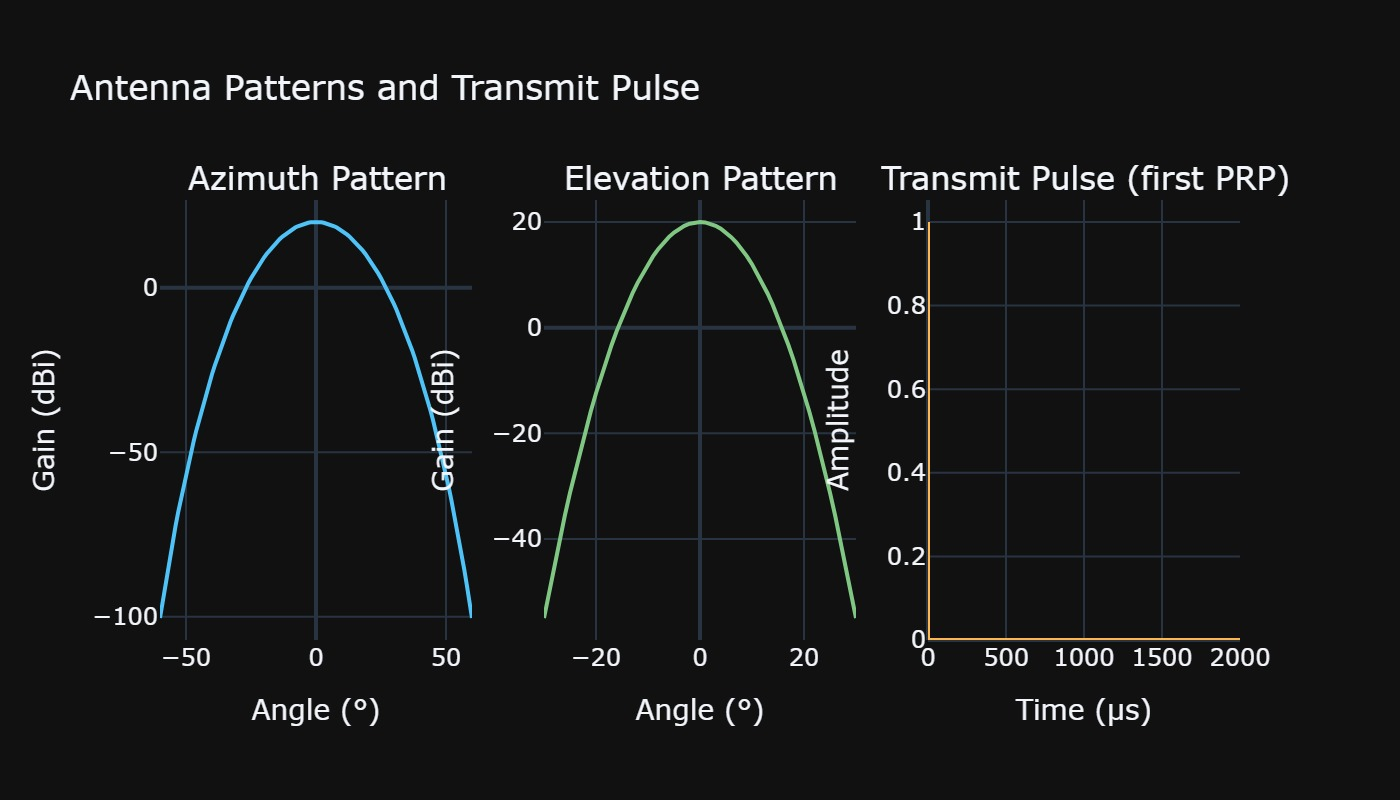

In [5]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Azimuth Pattern", "Elevation Pattern", "Transmit Pulse (first PRP)"),
)

fig.add_trace(
    go.Scatter(x=az_angle, y=az_pattern, name="Azimuth",
               line=dict(color="#4FC3F7", width=2)),
    row=1, col=1,
)
fig.add_trace(
    go.Scatter(x=el_angle, y=el_pattern, name="Elevation",
               line=dict(color="#81C784", width=2)),
    row=1, col=2,
)

t_us = mod_t[:samples_per_pulse] * 1e6  # µs
fig.add_trace(
    go.Scatter(
        x=t_us, y=amp[:samples_per_pulse],
        name="Amplitude", line=dict(color="#FFB74D", width=2), fill="tozeroy",
    ),
    row=1, col=3,
)

fig.update_xaxes(title_text="Angle (°)", row=1, col=1)
fig.update_xaxes(title_text="Angle (°)", row=1, col=2)
fig.update_xaxes(title_text="Time (µs)", row=1, col=3)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=1)
fig.update_yaxes(title_text="Gain (dBi)", row=1, col=2)
fig.update_yaxes(title_text="Amplitude", row=1, col=3)

fig.update_layout(
    title="Antenna Patterns and Transmit Pulse",
    template="plotly_dark", height=400, showlegend=False,
)
show(fig)

### Receiver Configuration

The receiver is co-located with the transmitter (monostatic SAR).
The baseband sampling rate matches the ADC rate ($f_s = 2B$).

In [6]:
rx_channel = dict(
    location=(0, 0, 0),
    azimuth_angle=az_angle,
    azimuth_pattern=az_pattern,
    elevation_angle=el_angle,
    elevation_pattern=el_pattern,
)

rx = Receiver(
    fs=fs,
    noise_figure=5,    # NF = 5 dB
    rf_gain=20,        # LNA gain = 20 dB
    baseband_gain=30,  # Baseband gain = 30 dB
    channels=[rx_channel],
)

print("Receiver configured.")
print(f"  Sample rate    : {fs/1e6:.0f} MHz")
print(f"  Samples/pulse  : {samples_per_pulse}")

Receiver configured.
  Sample rate    : 60 MHz
  Samples/pulse  : 120000


## Platform Trajectory and Scene Setup

For strip-map SAR the platform flies in a straight line (along +x) at constant
height.  A `frame_time` array supplied to the `Radar` object positions the radar
at a different along-track location for each pulse.

### Platform Trajectory

In [7]:
# Each pulse is transmitted at a different along-track position.
pulse_times = np.arange(num_pulses) * prp   # [0, PRP, 2*PRP, ...]
pulse_times -= pulse_times.mean()            # centre the aperture at x = 0

# Platform flies along +x; scene is in the XY-plane
platform_x = v_platform * pulse_times       # along-track positions (m)

aperture_len = platform_x[-1] - platform_x[0]
print(f"Pulse positions: x = {platform_x[0]:.1f} to {platform_x[-1]:.1f} m "
      f"(aperture = {aperture_len:.1f} m)")

Pulse positions: x = -5.9 to 5.9 m (aperture = 11.8 m)


### Radar Object

A single `Radar` with `frame_time` covering all pulse instants and a matching
`location` array (one row per pulse) models the moving platform.

In [8]:
# location: (num_pulses, 3) — one [x, y, z] position per frame
# locations = np.column_stack([
#     platform_x,
#     np.zeros(num_pulses),   # no cross-track offset
#     np.zeros(num_pulses),   # altitude 0 (2-D geometry)
# ])

radar = Radar(
    transmitter=tx,
    receiver=rx,
    # rotation=[90, 0, 0],
    # location=locations,      # (num_pulses, 3)
    # frame_time=pulse_times,  # (num_pulses,) in seconds
)

locations = [radar.time_prop["timestamp"]*v_platform,0,0]

radar.set_motion(location=locations, rotation=[90, 0, 0])

print(f"Radar created with {num_pulses} frames (pulses).")

Radar created with 60 frames (pulses).


In [9]:
radar.time_prop["timestamp_shape"]

(1, 60, 120000)

### Scene: Three Point Targets

Three point scatterers are placed at different along-track ($x$) and cross-track
($y$) positions:

| Target | x (m) | y (m) | RCS (dBsm) |
|--------|-------|-------|------------|
| A      |   0   | 1000  |  10        |
| B      | +20   | 1000  |   5        |
| C      |  +5   | 1020  |   0        |

Targets A and B are at the same range but 20 m apart in azimuth
(testing azimuth resolution).
Target C is 20 m further in range than A (testing range resolution).

In [10]:
targets = [
    {"location": (0.0,  r0,      0.0), "rcs": 10.0, "phase": 0.0},  # A: centre
    {"location": (20.0, r0,      0.0), "rcs":  5.0, "phase": 0.0},  # B: +20 m az
    {"location": (5.0,  r0 + 20, 0.0), "rcs":  0.0, "phase": 0.0},  # C: +20 m range
]

print("Targets:")
for i, t in enumerate(targets):
    x, y, z = t["location"]
    slant = np.hypot(y, x)
    print(f"  Target {chr(65+i)}: x={x:+.1f} m, y={y:.0f} m  "
          f"(slant R ≈ {slant:.1f} m)  RCS = {t['rcs']} dBsm")

Targets:
  Target A: x=+0.0 m, y=1000 m  (slant R ≈ 1000.0 m)  RCS = 10.0 dBsm
  Target B: x=+20.0 m, y=1000 m  (slant R ≈ 1000.2 m)  RCS = 5.0 dBsm
  Target C: x=+5.0 m, y=1020 m  (slant R ≈ 1020.0 m)  RCS = 0.0 dBsm


## Radar Simulation

Run the scene simulation using `sim_radar`.  The result contains the complex
baseband signal `baseband` with shape `(rx_channels, num_pulses, samples_per_pulse)`.

In [11]:
data = sim_radar(radar, targets, density=1)

baseband = data["baseband"]    # complex I/Q: (rx_ch, pulses, fast-time samples)
timestamp = data["timestamp"]  # time stamps:  (rx_ch, pulses, fast-time samples)

print("Simulation complete.")
print(f"  baseband shape : {baseband.shape}")
print(f"    dim 0 : {baseband.shape[0]} RX channel(s)")
print(f"    dim 1 : {baseband.shape[1]} pulses (synthetic aperture)")
print(f"    dim 2 : {baseband.shape[2]} fast-time samples per pulse")

Simulation complete.
  baseband shape : (1, 60, 120000)
    dim 0 : 1 RX channel(s)
    dim 1 : 60 pulses (synthetic aperture)
    dim 2 : 120000 fast-time samples per pulse


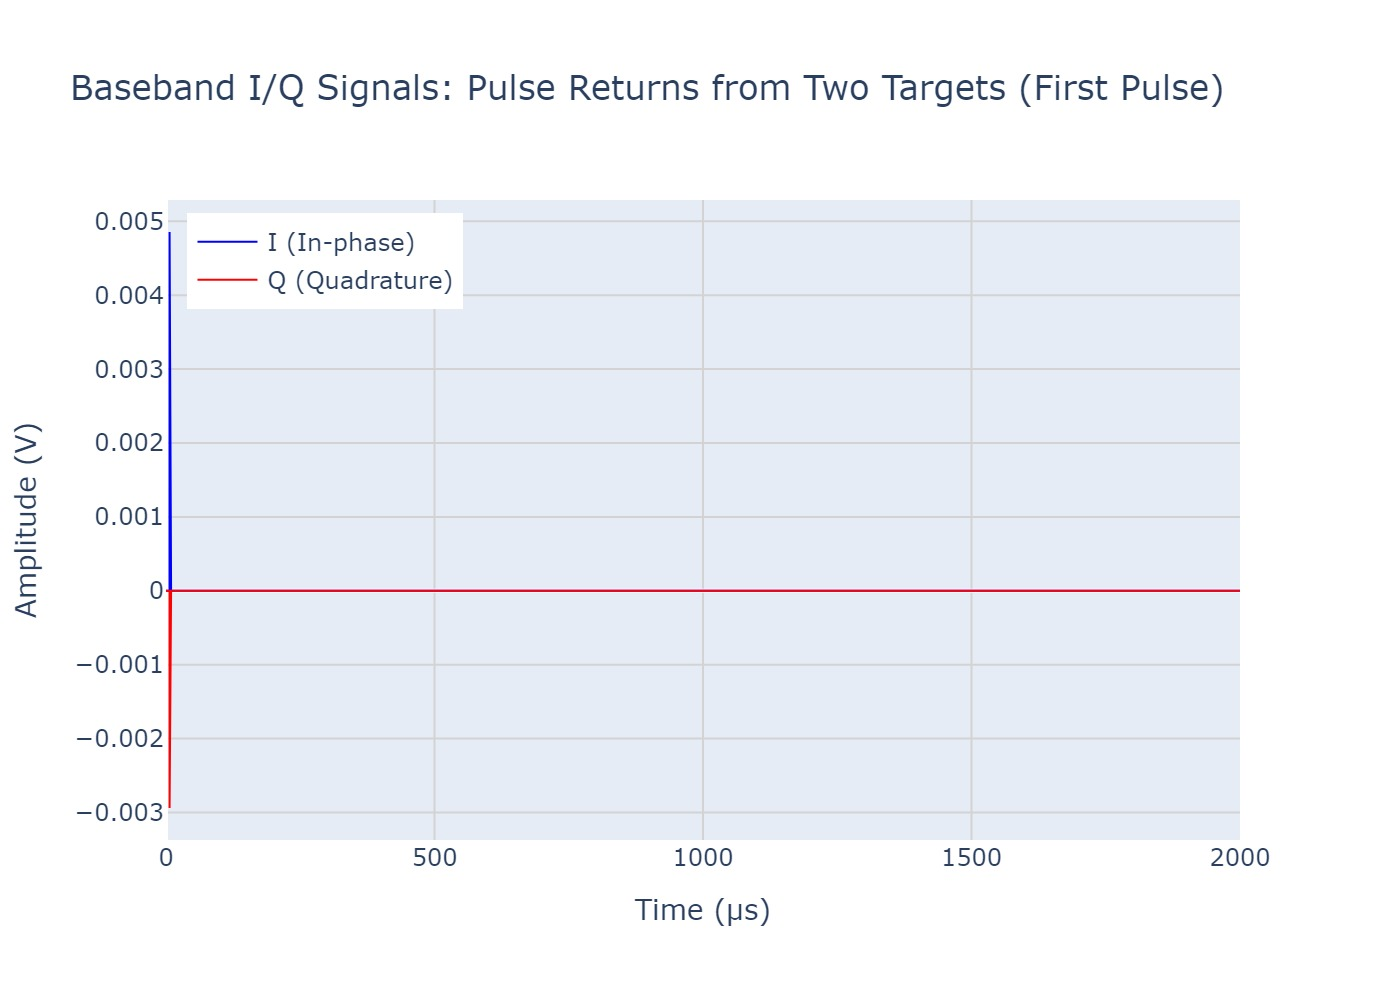

In [12]:
# Create figure for baseband I/Q visualization
fig = go.Figure()

# Plot In-phase (I) component
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :] * 1e6,  # Convert to microseconds
        y=np.real(baseband[0, 0, :]),  # Real part (I channel)
        name="I (In-phase)",
        line=dict(color="blue", width=1),
    )
)

# Plot Quadrature (Q) component
fig.add_trace(
    go.Scatter(
        x=timestamp[0, 0, :] * 1e6,  # Convert to microseconds
        y=np.imag(baseband[0, 0, :]),  # Imaginary part (Q channel)
        name="Q (Quadrature)",
        line=dict(color="red", width=1),
    )
)

# Configure plot layout
fig.update_layout(
    title="Baseband I/Q Signals: Pulse Returns from Two Targets (First Pulse)",
    yaxis=dict(title="Amplitude (V)", gridcolor="lightgray"),
    xaxis=dict(title="Time (μs)", gridcolor="lightgray"),
    height=500,
    legend=dict(x=0.02, y=0.98),
)

# uncomment this to display interactive plot
# fig.show()

# display static image to reduce size on radarsimx.com
img_bytes = fig.to_image(format="jpg", scale=2)
display(Image(img_bytes))

### Visualize Raw Phase History (Range–Azimuth)

The raw **phase history** matrix shows received signal amplitude for each
(pulse, fast-time sample) pair before focusing.  The hyperbolic tracks of the
three targets are visible — each target's echo bows due to the changing slant
range as the platform flies past.

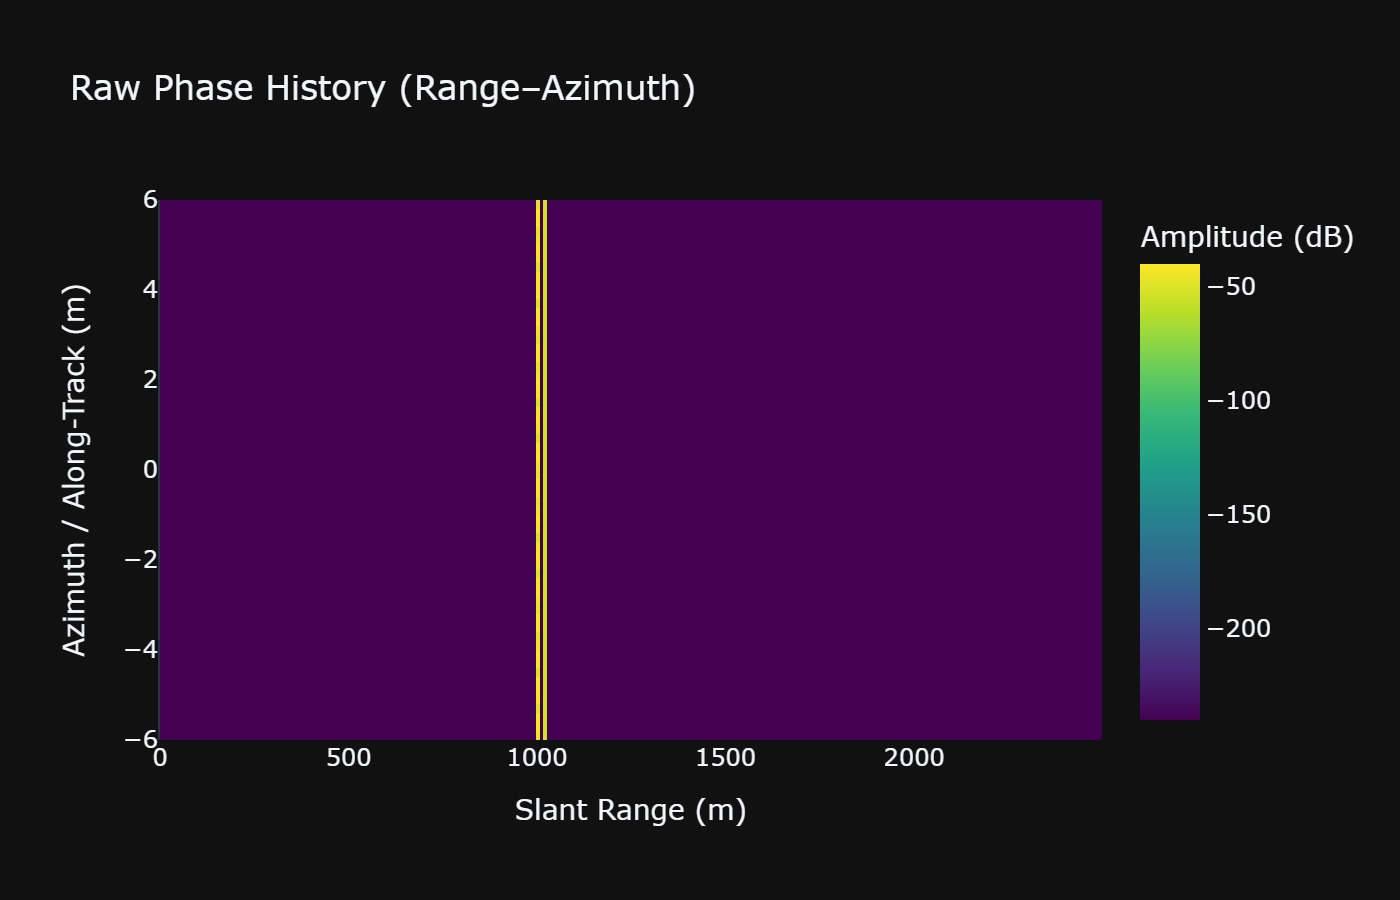

In [17]:
raw = baseband[0,:,:]  # single RX channel: (num_pulses, samples_per_pulse)

# Fast-time → slant range axis
fast_time = np.arange(samples_per_pulse) / fs
slant_range = fast_time * c / 2

az_positions = platform_x  # along-track positions of each pulse

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=slant_range, y=az_positions,
        z=20 * np.log10(np.abs(baseband[0,:,0:1000]) + 1e-12),
        colorscale="Viridis",
        colorbar=dict(title="Amplitude (dB)"),
        # zmin=-60, zmax=0,
    )
)
fig.update_layout(
    title="Raw Phase History (Range–Azimuth)",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark", height=450,
)
show(fig)

## SAR Processing: Back-Projection Algorithm (BPA)

BPA focuses each image pixel by phase-correcting and coherently summing the
contributions from all pulses.

For pixel $(x_p, y_p)$ and pulse $n$ at position $(x_n, 0)$:

$$R_n(x_p, y_p) = \sqrt{(x_p - x_n)^2 + y_p^2}$$

The echo of pulse $n$ at fast-time delay $\tau_n = 2R_n / c$ is extracted by
interpolating the matched-filtered baseband signal and phase-corrected:

$$I(x_p, y_p) = \sum_n s_n(\tau_n) \cdot e^{+j 4\pi R_n / \lambda}$$

### Step 1: Range Matched Filtering

Apply a matched filter to each pulse to compress the rectangular pulse in range.

In [18]:
# ── Matched filter (replica correlation) ─────────────────────────────────────
pulse_samples = int(np.ceil(pulse_width * fs))
replica = np.zeros(samples_per_pulse, dtype=complex)
replica[:pulse_samples] = 1.0   # rectangular pulse replica

# Convolve each pulse with the conjugate-time-reversed replica via FFT
NFFT = samples_per_pulse
REPLICA_FFT = np.fft.fft(np.conj(replica[::-1]), NFFT)

raw_mf = np.zeros_like(raw)
for i in range(num_pulses):
    raw_mf[i] = np.fft.ifft(np.fft.fft(raw[i], NFFT) * REPLICA_FFT)

print(f"Range matched filtering complete.  Shape: {raw_mf.shape}")
print(f"  Range resolution after MF : {range_res:.2f} m  (c / 2B)")

Range matched filtering complete.  Shape: (60, 120000)
  Range resolution after MF : 5.00 m  (c / 2B)


### Step 2: Visualize Range-Compressed Phase History

After range compression the pulse width contracts to $c/(2B)$ and the target
echoes become sharper in range.  The hyperbolic shape is now clearly visible.

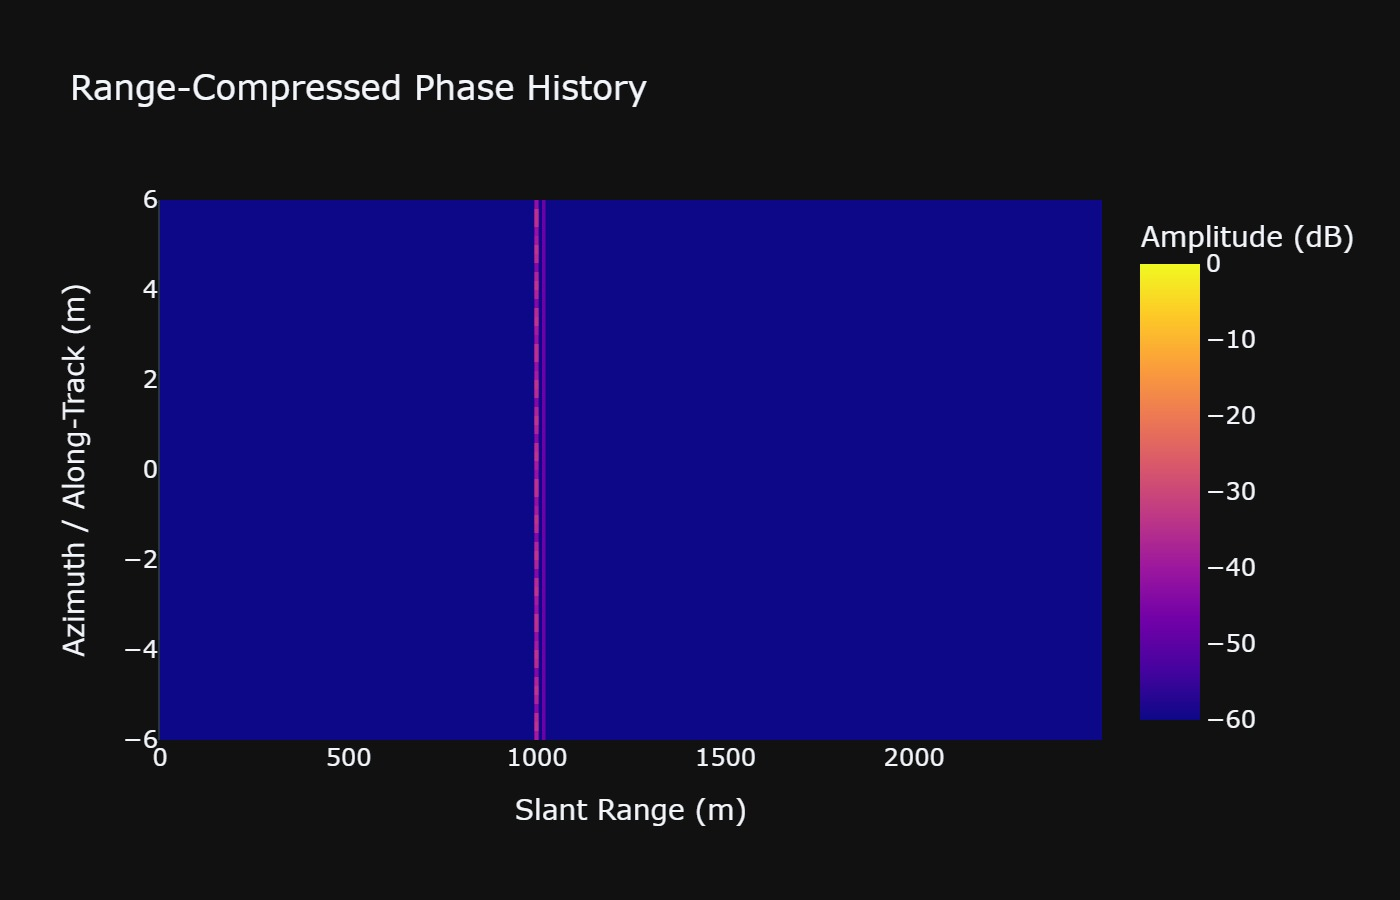

In [21]:
fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=slant_range, y=az_positions,
        z=20 * np.log10(np.abs(raw_mf[:, 0:1000]) + 1e-12),
        colorscale="Plasma",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-60, zmax=0,
    )
)
fig.update_layout(
    title="Range-Compressed Phase History",
    xaxis_title="Slant Range (m)",
    yaxis_title="Azimuth / Along-Track (m)",
    template="plotly_dark", height=450,
)
show(fig)

### Step 3: Back-Projection Focusing

Coherently integrate all pulses into a 2-D focused SAR image.

**Image grid**: discretised at half the resolution in both dimensions (2× oversampling).

In [22]:
# ── Image grid ────────────────────────────────────────────────────────────────
range_window = 60          # ±60 m around r0
range_step   = range_res / 2   # 2× oversampled
img_ranges   = np.arange(r0 - range_window, r0 + range_window + range_step, range_step)

az_window  = 40            # ±40 m
az_step    = az_res_sar / 2    # 2× oversampled
img_az     = np.arange(-az_window, az_window + az_step, az_step)

print(f"Image grid: {len(img_az)} az × {len(img_ranges)} range pixels")
print(f"  Azimuth : {img_az[0]:.1f} to {img_az[-1]:.1f} m  (step {az_step:.2f} m)")
print(f"  Range   : {img_ranges[0]:.1f} to {img_ranges[-1]:.1f} m  (step {range_step:.2f} m)")

# ── Back-projection ────────────────────────────────────────────────────────────
sar_image = np.zeros((len(img_az), len(img_ranges)), dtype=complex)
sample_coords = np.arange(samples_per_pulse)

for pulse_idx in range(num_pulses):
    x_n = platform_x[pulse_idx]

    # Instantaneous slant range from this pulse position to every image pixel
    # dx: (1, Naz),  dy: (Nr, 1)  →  R_n: (Nr, Naz)
    dx  = img_az[np.newaxis, :] - x_n
    dy  = img_ranges[:, np.newaxis]
    R_n = np.sqrt(dx**2 + dy**2)

    # Convert slant range to fractional fast-time sample index
    sample_idx = 2.0 * R_n / c * fs

    # Validity mask — only interpolate inside the sampled window
    valid = (sample_idx >= 0) & (sample_idx < samples_per_pulse - 1)
    si_flat = sample_idx.ravel()

    # Linear interpolation of matched-filtered pulse
    pulse_signal = raw_mf[pulse_idx]
    interp_re = np.interp(si_flat, sample_coords, pulse_signal.real, left=0.0, right=0.0)
    interp_im = np.interp(si_flat, sample_coords, pulse_signal.imag, left=0.0, right=0.0)
    interp_sig = (interp_re + 1j * interp_im).reshape(R_n.shape)
    interp_sig[~valid] = 0.0

    # Phase correction (removes carrier phase variation across aperture)
    phase_corr = np.exp(1j * 4.0 * np.pi * R_n / lam)

    # Accumulate: transpose so rows = azimuth, cols = range
    sar_image += (interp_sig * phase_corr).T

print("Back-projection complete.")
print(f"  SAR image shape : {sar_image.shape}  (Naz × Nr)")

Image grid: 321 az × 50 range pixels
  Azimuth : -40.0 to 40.0 m  (step 0.25 m)
  Range   : 940.0 to 1062.4 m  (step 2.50 m)
Back-projection complete.
  SAR image shape : (321, 50)  (Naz × Nr)


## Results: Focused SAR Image

### 2-D SAR Image

Three bright spots correspond to the three point targets.
Targets A and B are well resolved in azimuth;
targets A and C are well resolved in range.

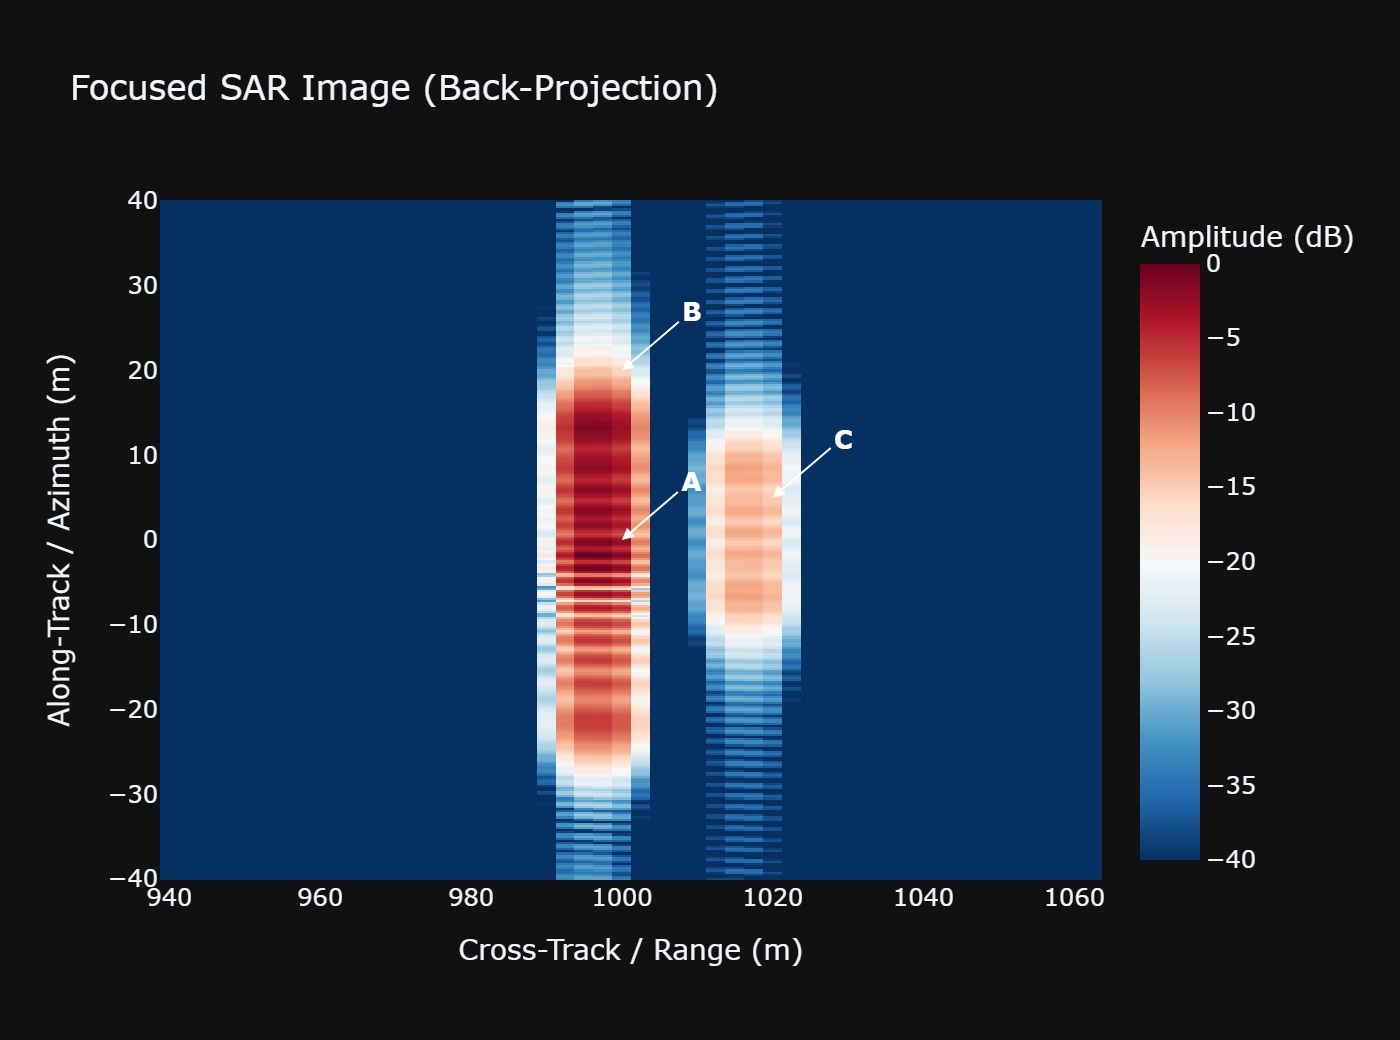

In [23]:
sar_amp_db = 20 * np.log10(np.abs(sar_image) + 1e-12)
sar_amp_db -= sar_amp_db.max()   # normalise to 0 dB

fig = go.Figure()
fig.add_trace(
    go.Heatmap(
        x=img_ranges, y=img_az,
        z=sar_amp_db,
        colorscale="RdBu_r",
        colorbar=dict(title="Amplitude (dB)"),
        zmin=-40, zmax=0,
    )
)

# Annotate ground-truth target positions
for tgt, lbl in zip(targets, ["A", "B", "C"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_annotation(
        x=y_t, y=x_t, text=f"<b>{lbl}</b>",
        showarrow=True, arrowhead=2, arrowcolor="white",
        font=dict(color="white", size=13), arrowsize=1.2, ax=35, ay=-30,
    )

fig.update_layout(
    title="Focused SAR Image (Back-Projection)",
    xaxis_title="Cross-Track / Range (m)",
    yaxis_title="Along-Track / Azimuth (m)",
    template="plotly_dark", height=520,
)
show(fig)

### Range Profile Through Target A

Slice at azimuth = 0 m (Target A) to confirm range resolution.
Targets A and C (20 m apart in range, >> ΔR = 5 m) should appear as separate peaks.

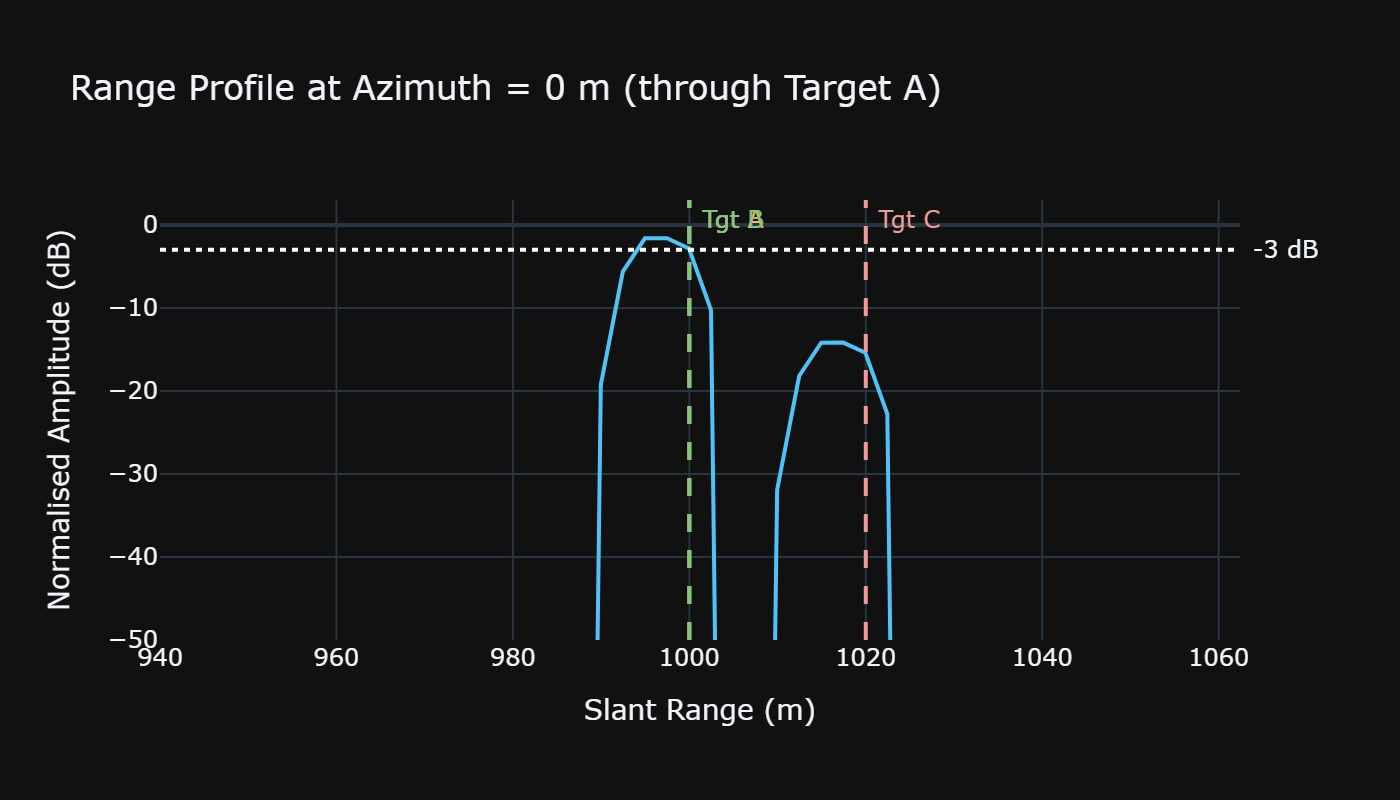

In [24]:
az_idx_A  = np.argmin(np.abs(img_az - 0.0))
range_slice = sar_amp_db[az_idx_A, :]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=img_ranges, y=range_slice,
        mode="lines", name="Range profile",
        line=dict(color="#4FC3F7", width=2),
    )
)
for tgt, lbl, col in zip(targets, ["A", "B", "C"],
                          ["#FFB74D", "#81C784", "#EF9A9A"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_vline(x=y_t, line_dash="dash", line_color=col,
                  annotation_text=f" Tgt {lbl}",
                  annotation_position="top right",
                  annotation_font_color=col)

fig.add_hline(y=-3, line_dash="dot", line_color="white",
              annotation_text=" -3 dB", annotation_position="right")

fig.update_layout(
    title="Range Profile at Azimuth = 0 m (through Target A)",
    xaxis_title="Slant Range (m)",
    yaxis_title="Normalised Amplitude (dB)",
    yaxis=dict(range=[-50, 3]),
    template="plotly_dark", height=400,
)
show(fig)

### Azimuth Profile at Broadside Range

Slice at range = 1000 m (broadside) to confirm azimuth resolution.
Targets A and B (20 m apart in azimuth, >> Δaz = 0.5 m) should appear as
two distinct peaks.

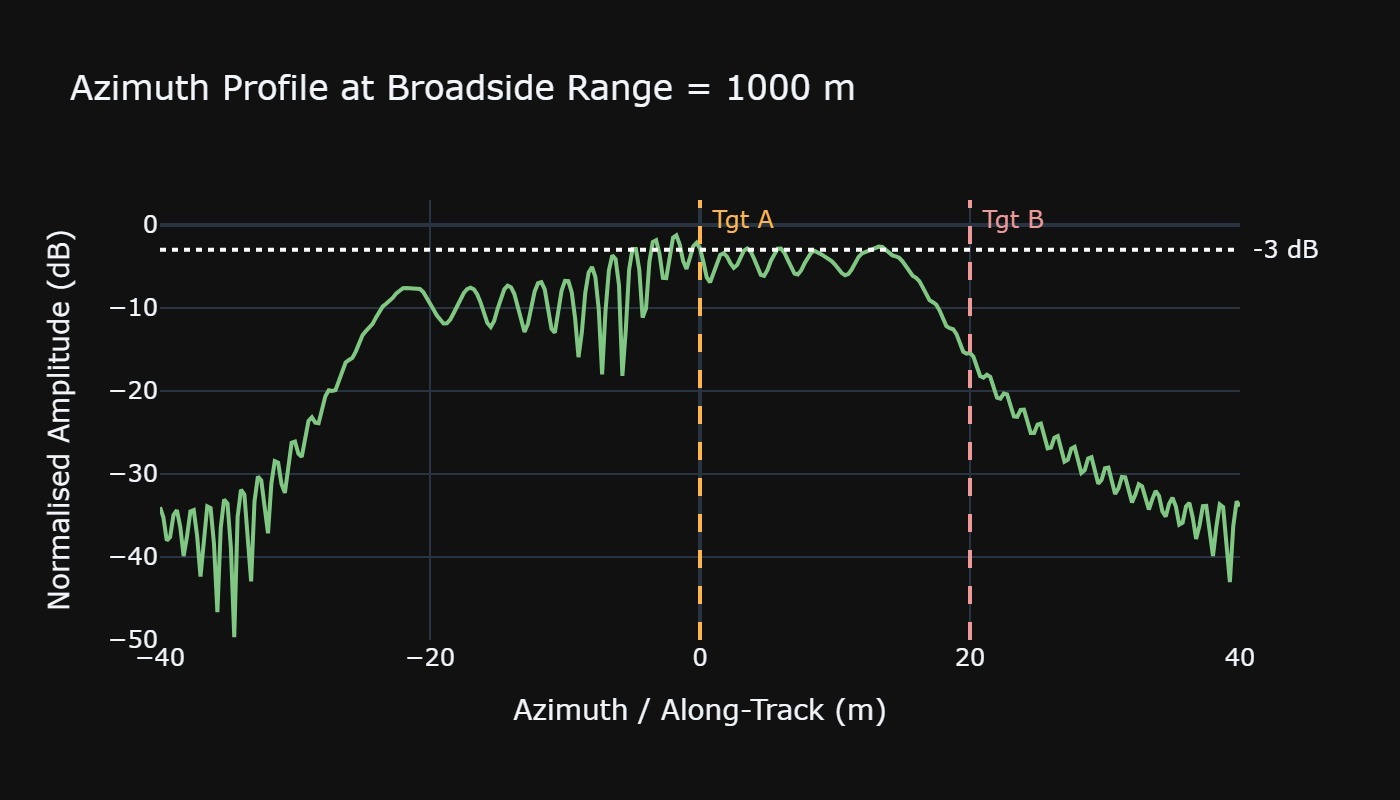

In [25]:
rng_idx_r0 = np.argmin(np.abs(img_ranges - r0))
az_slice = sar_amp_db[:, rng_idx_r0]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=img_az, y=az_slice,
        mode="lines", name="Azimuth profile",
        line=dict(color="#81C784", width=2),
    )
)
for tgt, lbl, col in zip(targets[:2], ["A", "B"],
                          ["#FFB74D", "#EF9A9A"]):
    x_t, y_t, _ = tgt["location"]
    fig.add_vline(x=x_t, line_dash="dash", line_color=col,
                  annotation_text=f" Tgt {lbl}",
                  annotation_position="top right",
                  annotation_font_color=col)

fig.add_hline(y=-3, line_dash="dot", line_color="white",
              annotation_text=" -3 dB", annotation_position="right")

fig.update_layout(
    title=f"Azimuth Profile at Broadside Range = {r0:.0f} m",
    xaxis_title="Azimuth / Along-Track (m)",
    yaxis_title="Normalised Amplitude (dB)",
    yaxis=dict(range=[-50, 3]),
    template="plotly_dark", height=400,
)
show(fig)

## Summary

This notebook demonstrated a complete X-band strip-map SAR simulation with `RadarSimPy`:

| Step | Description | Key result |
|------|-------------|------------|
| 1 | System design | $f_c$ = 10 GHz, $B$ = 30 MHz, PRF = 500 Hz |
| 2 | Moving platform | $v$ = 100 m/s, 60 pulses, aperture ≈ 11.9 m |
| 3 | Scene | 3 point targets at 1 000 – 1 020 m range |
| 4 | Simulation | `sim_radar` → complex baseband (60 × 120 000 samples) |
| 5 | Range MF | Pulse compression → ΔR ≈ 5 m |
| 6 | Back-Projection | Coherent focusing → Δaz ≈ 0.5 m |

The focused SAR image successfully resolves:

- **Targets A and B**: 20 m apart in azimuth (>> Δaz ≈ 0.5 m).
- **Targets A and C**: 20 m apart in range (>> ΔR ≈ 5 m).

The Back-Projection Algorithm (BPA) is the simplest exact SAR focusing method.
More efficient alternatives include the **Range-Doppler Algorithm (RDA)** and
**ω-k (Stolt migration)**, which achieve the same quality with $O(N \log N)$
complexity for large scenes.